<a href="https://colab.research.google.com/github/TeeterJL/INFO648/blob/main/INFO648%20/%20Capstone%20/%20CAAA_Overrun_EarlyWarning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CAAA Predictive Overrun Early-Warning System
### Crane Army Ammunition Activity — Capstone | Adrian Audirac, Jacob Teeter

This notebook implements a **Predictive Overrun Early-Warning System** for munitions
production projects. It is organized around the three capstone questions:

| # | Question | Module in this notebook |
|---|----------|-------------------------|
| **Q1** | Which project factors (contract type, complexity, workforce, cost trends) are the strongest early predictors of overrun? | **§4 Feature Engineering** + **§7 Predictor Importance** |
| **Q2** | At what point in the lifecycle do overruns become *detectable*, and what leading indicators precede the breach? | **§5 Early-Warning Engine** (EVM-style burn-curve analysis) |
| **Q3** | Which attributes are statistically strongest, and how do we operationalize them into a repeatable risk score? | **§6 Risk-Scoring Framework** |

---
## ⚠️ Read this first — what this model can and cannot do

The dataset provided contains **exactly two projects** — `HH22` (120 mm VL Candle / M930)
and `WG22` (155 mm Illum Candle / M1124) — and **both overran budget**
(HH22 **+54%**, WG22 **+15%**).

You **cannot** train a supervised machine-learning classifier that *generalizes* from two
same-label examples. Any model claiming to "learn which projects overrun" from N=2 would be
statistically meaningless. This notebook is therefore built in two layers:

1. **An expert-weighted, transparent risk-scoring engine + a time-series early-warning
   engine** that run *today* on the data you have. These are defensible because they rely on
   documented program-management logic (EVM, cost-variance analysis), not on fitting a curve
   to two points.
2. **A trained-model hook (§7)** that *automatically activates* a logistic-regression /
   gradient-boosted classifier and reports fitted predictor importances **as soon as you load
   enough labeled historical projects** (rule of thumb: ≥ ~15 projects with both outcomes
   present). The same notebook becomes a true predictive model when CAAA drops more project
   folders into the registry.

**The most important empirical finding from the two projects:** they overran for *opposite*
reasons — HH22 on **labor** (2.1× planned labor), WG22 on **material** (4.75× planned
material, while its labor came in *under*). That is the entire justification for a
**multi-indicator** framework instead of a single metric.

## §1 · Setup

Run this on **Google Colab**. All libraries below ship with Colab by default; the `pip`
line is only a safety net.

In [1]:
# Safe in Colab; these are usually pre-installed.
!pip install -q pandas numpy matplotlib scikit-learn openpyxl

import os, io, json, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
print("Environment ready.")

Environment ready.


## §2 · Load the data files

Two ways to provide the files:

* **Option A (recommended in Colab):** run the upload cell and pick all 9 files at once.
* **Option B:** mount Google Drive / set `DATA_DIR` to a folder that contains them.

Expected files (case-insensitive match on the names below):

```
HH22_AND_WG22_OVERVIEW.XLSX   <- authoritative budget vs actual (both projects)
HH22_COSTS.XLSX  / WG22_COSTS.XLSX        <- transaction-level cost postings (time series)
HH22_COST_PLAN.XLSX / WG22_COST_PLAN.XLSX <- planned cost (Sheet1 = $, Sheet2 = labor hrs)
HH22_BOM.xlsx / WG22_BOM.xlsx             <- bill of materials
HH22_and_WG22_Routes.docx                 <- routing (image only; op counts entered in §3)
```

In [2]:
DATA_DIR = "."   # change if using Drive, e.g. "/content/drive/MyDrive/CAAA"

def _in_colab():
    try:
        import google.colab  # noqa
        return True
    except Exception:
        return False

if _in_colab():
    from google.colab import files
    print("Select all of your *.xlsx / *.docx files (Ctrl/Cmd-click to multi-select)...")
    uploaded = files.upload()           # saves into the working dir (".")
    DATA_DIR = "."
else:
    print(f"Not in Colab. Reading files from DATA_DIR = {os.path.abspath(DATA_DIR)}")

def find_file(*needles):
    """Case-insensitive search for a file whose name contains all needles."""
    needles = [n.lower() for n in needles]
    for fn in os.listdir(DATA_DIR):
        low = fn.lower()
        if all(n in low for n in needles):
            return os.path.join(DATA_DIR, fn)
    return None

print("\nDiscovered files:")
for label, needles in {
    "overview":   ("overview",),
    "HH22 costs": ("hh22", "cost") , "WG22 costs": ("wg22", "cost"),
    "HH22 plan":  ("hh22", "cost_plan"), "WG22 plan": ("wg22", "cost_plan"),
    "HH22 bom":   ("hh22", "bom"), "WG22 bom": ("wg22", "bom"),
}.items():
    print(f"  {label:12s}: {find_file(*needles)}")

Select all of your *.xlsx / *.docx files (Ctrl/Cmd-click to multi-select)...


Saving HH22 AND WG22 OVERVIEW.XLSX to HH22 AND WG22 OVERVIEW.XLSX
Saving HH22 and WG22 Routes.docx to HH22 and WG22 Routes.docx
Saving HH22 BOM.xlsx to HH22 BOM.xlsx
Saving HH22 COST PLAN.XLSX to HH22 COST PLAN.XLSX
Saving HH22 COSTS.XLSX to HH22 COSTS.XLSX
Saving WG22 BOM.xlsx to WG22 BOM.xlsx
Saving WG22 COST PLAN.XLSX to WG22 COST PLAN.XLSX
Saving WG22 COSTS.XLSX to WG22 COSTS.XLSX

Discovered files:
  overview    : ./HH22 AND WG22 OVERVIEW.XLSX
  HH22 costs  : ./HH22 COSTS.XLSX
  WG22 costs  : ./WG22 COSTS.XLSX
  HH22 plan   : None
  WG22 plan   : None
  HH22 bom    : ./HH22 BOM.xlsx
  WG22 bom    : ./WG22 BOM.xlsx


## §3 · Project registry (configuration)

This is the single place you extend the system. To add a new project later, append a
`ProjectSpec` with its file name fragments and a few facts that live outside the
spreadsheets (the **routing operation count**, which in the source data is only an image,
and the customer/contract descriptors).

The routing op-counts below were read from the route diagrams in the `.docx`:
`HH22 = 7 operations`, `WG22 = 6 operations` (HH22 has an extra *Swivel Assembly* step).

In [3]:
import os, io, json, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

@dataclass
class ProjectSpec:
    key: str                       # short id, must match the COSTS/BOM file prefix
    overview_id: str               # value in OVERVIEW 'Project Definition'
    costs_needles: tuple
    plan_needles: tuple
    bom_needles: tuple
    n_route_ops: int               # from the routing diagram (not in the spreadsheets)
    contract_type: str = "F"       # Proj Type ('F' = funded/firm here)
    description: str = ""

PROJECTS = [
    ProjectSpec("HH22", "HH22AB02A2HHM3", ("hh22","costs"), ("hh22","cost","plan"),
                ("hh22","bom"), n_route_ops=7, description="120mm VL Candle f/ M930"),
    ProjectSpec("WG22", "WG22AA22A8HHM3", ("wg22","costs"), ("wg22","cost","plan"),
                ("wg22","bom"), n_route_ops=6, description="155mm Illum Candle f/ M1124"),
    # --- ADD MORE HISTORICAL PROJECTS HERE to unlock the trained model in §7 ---
]
print(f"{len(PROJECTS)} project(s) registered: {[p.key for p in PROJECTS]}")

2 project(s) registered: ['HH22', 'WG22']


## §4 · Loaders, cleaning & feature engineering

### Data-quality note that matters
The raw `*_COSTS` files sum to **exactly 2.000×** the authoritative `Act Cost Total` in the
overview, for *both* projects — a duplicated-export artifact. We treat the **overview** as
ground truth for budget/actual, and we **reconcile** the transaction time-series by a scale
factor so its cumulative shape ends at the true actual. The *shape* of the burn curve (what
the early-warning engine needs) is unaffected by the scaling.

### Features are grouped to match Q1's four factor families
* **Contract / programmatic** — contract type, customer, supplier concentration
* **Complexity** — routing operations, BOM line count, energetic-material flag, distinct
  labor cost centers, authorized quantity
* **Workforce** — actual÷planned hours, overtime share, labor-cost variance, realized vs.
  planned labor rate
* **Cost trend / execution** — material-cost variance, reversals, cost transfers, late-stage
  spend share, monthly burn volatility

In [4]:
VAL = "Val/COArea Crcy"

def _clean_cols(df):
    df.columns = [str(c).strip() for c in df.columns]
    return df

def load_overview():
    f = find_file("overview")
    df = _clean_cols(pd.read_excel(f))
    df["Project Definition"] = df["Project Definition"].astype(str).str.strip()
    return df

def overview_row(ov, spec):
    r = ov[ov["Project Definition"] == spec.overview_id]
    if len(r) == 0:
        raise ValueError(f"{spec.overview_id} not found in overview")
    return r.iloc[0]

def load_costs(spec):
    f = find_file(*spec.costs_needles)
    df = _clean_cols(pd.read_excel(f))
    df[VAL] = pd.to_numeric(df[VAL], errors="coerce")
    df["date"] = pd.to_datetime(df["Posting Date"], errors="coerce")
    df = df.dropna(subset=[VAL, "date"]).copy()
    desc = df["Cost element descr."].fillna("").str.lower()
    df["bucket"] = np.select(
        [desc.str.contains("overtime"),
         desc.str.contains("labor"),
         desc.str.contains("supplies|material|purchase|card", regex=True),
         desc.str.contains("warfare|contract", regex=True)],
        ["labor_ot", "labor_reg", "material", "contract"],
        default="other")
    df["is_reversal"]  = df[VAL] < 0
    txt = df.get("Document Header Text", pd.Series([""]*len(df))).fillna("").str.lower()
    df["is_transfer"]  = (df["Business Transaction"].astype(str).str.startswith("RKU")) | \
                          txt.str.contains("transfer|trasnfer")  # source typo preserved
    return df

def load_plan(spec):
    f = find_file(*spec.plan_needles)
    xl = pd.ExcelFile(f)
    cost = _clean_cols(pd.read_excel(f, sheet_name=xl.sheet_names[0]))
    labor = _clean_cols(pd.read_excel(f, sheet_name=xl.sheet_names[1])) if len(xl.sheet_names) > 1 else None
    return cost, labor

def load_bom(spec):
    f = find_file(*spec.bom_needles)
    return _clean_cols(pd.read_excel(f))

# ---- energetic / pyrotechnic material detector (complexity & risk driver) ----
ENERGETIC = ["nitrate","boron","magnesium","zirconium","hydride","tetranitro",
             "silicon","resin","candle","pyro","illum"]
def energetic_count(bom):
    d = bom["COMPONENT DESCRIPTION"].fillna("").str.lower()
    return int(sum(d.str.contains("|".join(ENERGETIC))))

def build_features():
    ov = load_overview()
    rows = []
    raw = {}   # keep loaded frames for the early-warning engine
    for spec in PROJECTS:
        o   = overview_row(ov, spec)
        costs = load_costs(spec)
        pcost, plabor = load_plan(spec)
        bom = load_bom(spec)

        budget   = float(o["Release Budget"])
        actual   = float(o["Act Cost Total"])
        pl_hrs   = float(o["Plan Hours"]);    ac_hrs = float(o["Actual Hours"])
        pl_lab   = float(o["Fnd Pln Cst-Lab"]); ac_lab = float(o["Act Cost Labor"])
        pl_mat   = float(o["Fnd Pln Cst-Mat"]); ac_mat = float(o["Act Cost Mat"])
        auth_qty = float(o["Authorized Qty"])

        # reconcile transaction series to authoritative actual
        raw_total = costs[VAL].sum()
        scale = actual / raw_total if raw_total else 1.0
        costs["val_adj"] = costs[VAL] * scale

        # supplier concentration: share of spend going to named contract partner (sole-source)
        contract_share = costs.loc[costs["bucket"]=="contract","val_adj"].sum() / actual
        ot_hours  = costs.loc[costs["bucket"]=="labor_ot","Total Quantity"].sum()
        reg_hours = costs.loc[costs["bucket"]=="labor_reg","Total Quantity"].sum()
        ot_share  = ot_hours / max(ot_hours + reg_hours, 1e-9)

        # monthly burn volatility (coefficient of variation of monthly spend)
        m = costs.set_index("date")["val_adj"].resample("MS").sum()
        burn_cv = (m.std() / m.mean()) if m.mean() else 0.0

        # late-stage spend share: fraction of spend in last 20% of the schedule window
        t0, t1 = costs["date"].min(), costs["date"].max()
        span = (t1 - t0).days or 1
        late_cut = t0 + pd.Timedelta(days=0.8*span)
        late_share = costs.loc[costs["date"] >= late_cut, "val_adj"].sum() / actual

        rows.append(dict(
            key=spec.key, description=spec.description, status=str(o["Status"]),
            # ---- ground-truth label ----
            budget=budget, actual=actual,
            overrun_pct=(actual/budget - 1)*100, overran=int(actual > budget),
            # ---- contract / programmatic ----
            contract_type=spec.contract_type, cust_code=str(o["Cust Code"]),
            supplier_concentration=contract_share,
            # ---- complexity ----
            n_route_ops=spec.n_route_ops, bom_lines=len(bom),
            energetic_lines=energetic_count(bom), authorized_qty=auth_qty,
            distinct_cost_centers=costs["Partner-CCtr"].nunique(),
            # ---- workforce ----
            hours_ratio=ac_hrs/pl_hrs if pl_hrs else np.nan,
            overtime_share=ot_share,
            labor_cost_ratio=ac_lab/pl_lab if pl_lab else np.nan,
            realized_rate=ac_lab/ac_hrs if ac_hrs else np.nan,
            planned_rate=pl_lab/pl_hrs if pl_hrs else np.nan,
            # ---- cost trend / execution ----
            material_cost_ratio=ac_mat/pl_mat if pl_mat else np.nan,
            reversals_per_100=100*costs["is_reversal"].sum()/len(costs),
            cost_transfers=int(costs["is_transfer"].sum()),
            late_stage_share=late_share, burn_cv=burn_cv,
        ))
        raw[spec.key] = dict(costs=costs, budget=budget, actual=actual, spec=spec)
    feats = pd.DataFrame(rows).set_index("key")
    feats["rate_inflation"] = feats["realized_rate"]/feats["planned_rate"]
    return feats, raw

FEATURES, RAW = build_features()
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
FEATURES.T

key,HH22,WG22
description,120mm VL Candle f/ M930,155mm Illum Candle f/ M1124
status,REL,CLSD
budget,"1,898,635.05","615,337.38"
actual,"2,927,249.95","705,835.97"
overrun_pct,54.18,14.71
overran,1,1
contract_type,F,F
cust_code,24,24
supplier_concentration,0.01,0.01
n_route_ops,7,6


## §5 · Early-Warning Engine  ·  *answers Q2*

**Method.** For each project we build the cumulative-spend curve from its postings and
compare it against an expected (planned) S-curve. We compute, month by month, EVM-style
indicators:

* **% budget consumed** vs **% schedule elapsed**
* **Overrun Index (OI)** = `%budget_consumed ÷ %schedule_elapsed`. Sustained `OI > 1` means
  the project is spending faster than the plan implies.
* **Projected EAC** (Estimate At Completion) = `cumulative_actual ÷ planned_%_complete`.
  When projected EAC first exceeds the budget by a tolerance, the overrun is *detectable*.

The **detection point** is the earliest month with a *sustained* breach (2+ consecutive
months) of either rule. We report it as a **% of the project lifecycle** so it is comparable
across projects of different lengths.

> The planned S-curve here is a standard logistic profile (front-to-back ramp typical of
> production lots). If you have a *time-phased* plan, drop it in to replace the heuristic.

In [5]:
def planned_scurve(frac, steepness=6.0):
    """Logistic cumulative-completion profile over schedule fraction (0..1)."""
    x = (frac - 0.5) * steepness
    lo, hi = 1/(1+np.exp(steepness*0.5)), 1/(1+np.exp(-steepness*0.5))
    return (1/(1+np.exp(-x)) - lo) / (hi - lo)

def early_warning(key, oi_thresh=1.05, eac_tol=1.10, sustain=2):
    d = RAW[key]; costs, budget, actual = d["costs"], d["budget"], d["actual"]
    m = costs.set_index("date")["val_adj"].resample("MS").sum().cumsum()
    t0, t1 = m.index.min(), m.index.max()
    span = (t1 - t0).days or 1
    sched = np.array([(ts - t0).days/span for ts in m.index])
    pct_budget = m.values / budget
    planned_complete = np.clip(planned_scurve(sched), 1e-3, 1.0)
    eac = m.values / planned_complete
    oi  = np.divide(pct_budget, np.clip(sched, 1e-3, 1.0))

    breach = (oi > oi_thresh) | (eac > eac_tol*budget)
    detect_idx = None
    run = 0
    for i, b in enumerate(breach):
        run = run + 1 if b else 0
        if run >= sustain:
            detect_idx = i - sustain + 1
            break

    res = pd.DataFrame({"month": m.index, "sched_pct": sched,
                        "cum_actual": m.values, "pct_budget": pct_budget,
                        "planned_complete": planned_complete,
                        "projected_EAC": eac, "overrun_index": oi, "breach": breach})
    summary = dict(key=key, budget=budget, final_actual=actual,
                   final_overrun_pct=(actual/budget-1)*100,
                   n_months=len(m),
                   detect_month=(str(m.index[detect_idx].date()) if detect_idx is not None else None),
                   detect_lifecycle_pct=(round(100*sched[detect_idx],1) if detect_idx is not None else None),
                   eac_at_detect=(round(eac[detect_idx],0) if detect_idx is not None else None))
    return res, summary

EW = {p.key: early_warning(p.key) for p in PROJECTS}
ew_summary = pd.DataFrame([s for _, s in EW.values()]).set_index("key")
print("EARLY-WARNING SUMMARY")
print(ew_summary.to_string())

EARLY-WARNING SUMMARY
           budget  final_actual  final_overrun_pct  n_months detect_month  detect_lifecycle_pct  eac_at_detect
key                                                                                                           
HH22 1,898,635.05  2,927,249.95              54.18        47   2025-08-01                 82.60   1,828,562.00
WG22   615,337.38    705,835.97              14.71        22   2024-05-01                 52.40   1,203,372.00


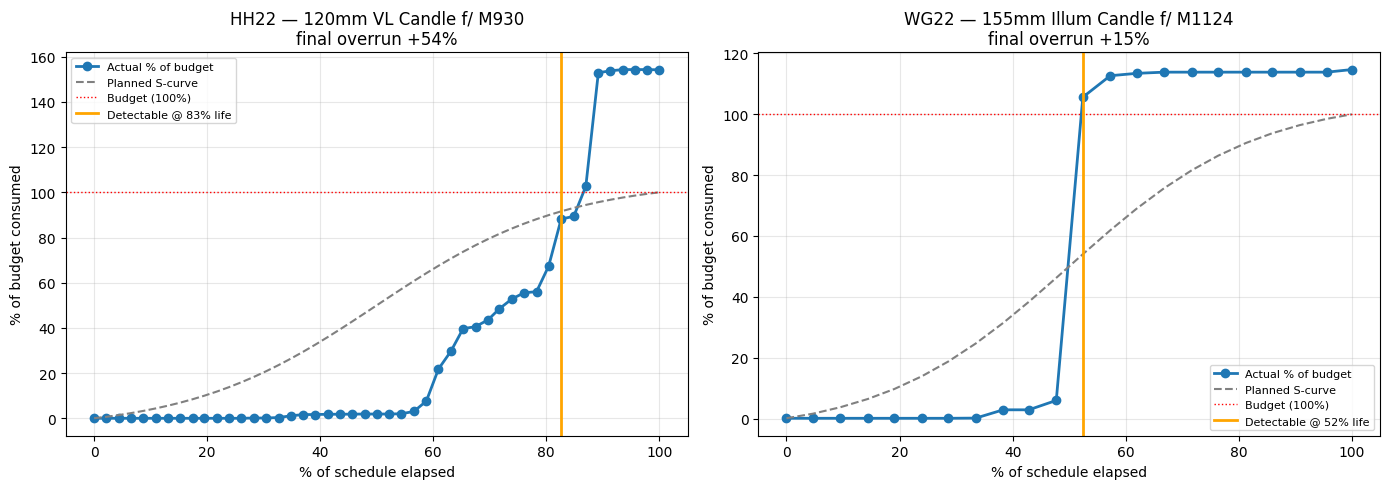

In [6]:
# ---- Visualize burn curves + detection points ----
fig, axes = plt.subplots(1, len(PROJECTS), figsize=(7*len(PROJECTS), 5), squeeze=False)
for ax, spec in zip(axes[0], PROJECTS):
    res, summ = EW[spec.key]
    ax.plot(res["sched_pct"]*100, res["pct_budget"]*100, "-o", lw=2, label="Actual % of budget")
    ax.plot(res["sched_pct"]*100, res["planned_complete"]*100, "--", color="gray", label="Planned S-curve")
    ax.axhline(100, color="red", ls=":", lw=1, label="Budget (100%)")
    if summ["detect_lifecycle_pct"] is not None:
        ax.axvline(summ["detect_lifecycle_pct"], color="orange", lw=2,
                   label=f"Detectable @ {summ['detect_lifecycle_pct']:.0f}% life")
    ax.set_title(f"{spec.key} — {spec.description}\nfinal overrun {summ['final_overrun_pct']:+.0f}%")
    ax.set_xlabel("% of schedule elapsed"); ax.set_ylabel("% of budget consumed")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §6 · Risk-Scoring Framework  ·  *answers Q3*

A **transparent, weighted, repeatable** score from **0–100**. Every indicator is normalized
to 0–1 by a documented threshold, weighted, and summed. Because the logic is explicit (not a
black-box fit to two points), it is auditable and deployable now, and the weights can be
**re-calibrated** from fitted coefficients once §7 has enough data.

| Family | Weight | Indicators |
|--------|:------:|-----------|
| Workforce | 0.30 | hours ratio, overtime share, labor-cost ratio, rate inflation |
| Cost trend / execution | 0.30 | material-cost ratio, reversals, cost transfers, late-stage spend, burn volatility |
| Complexity | 0.25 | routing ops, BOM lines, energetic lines, distinct cost centers |
| Contract / programmatic | 0.15 | supplier concentration, contract type |

Tiers: **0–24 Low · 25–49 Moderate · 50–74 High · 75–100 Critical**

In [7]:
def _ramp(x, lo, hi):
    """Linear 0..1 between lo and hi, clipped."""
    if x is None or (isinstance(x, float) and math.isnan(x)): return 0.0
    return float(np.clip((x - lo) / (hi - lo), 0, 1))

# Each indicator -> (sub-score 0..1) via a documented threshold ramp.
INDICATORS = {
    "workforce": (0.30, {
        "hours_ratio":      lambda r: _ramp(r.hours_ratio, 1.0, 1.5),
        "overtime_share":   lambda r: _ramp(r.overtime_share, 0.05, 0.30),
        "labor_cost_ratio": lambda r: _ramp(r.labor_cost_ratio, 1.0, 2.0),
        "rate_inflation":   lambda r: _ramp(r.rate_inflation, 1.0, 1.4),
    }),
    "cost_trend": (0.30, {
        "material_cost_ratio": lambda r: _ramp(r.material_cost_ratio, 1.0, 3.0),
        "reversals_per_100":   lambda r: _ramp(r.reversals_per_100, 0.0, 5.0),
        "cost_transfers":      lambda r: _ramp(r.cost_transfers, 0, 5),
        "late_stage_share":    lambda r: _ramp(r.late_stage_share, 0.10, 0.40),
        "burn_cv":             lambda r: _ramp(r.burn_cv, 0.5, 2.0),
    }),
    "complexity": (0.25, {
        "n_route_ops":           lambda r: _ramp(r.n_route_ops, 4, 12),
        "bom_lines":             lambda r: _ramp(r.bom_lines, 10, 40),
        "energetic_lines":       lambda r: _ramp(r.energetic_lines, 3, 15),
        "distinct_cost_centers": lambda r: _ramp(r.distinct_cost_centers, 2, 10),
    }),
    "contract": (0.15, {
        "supplier_concentration": lambda r: _ramp(r.supplier_concentration, 0.05, 0.50),
        "contract_type":          lambda r: 0.6 if str(r.contract_type) != "F" else 0.2,
    }),
}

def score_project(r):
    detail, family_scores = {}, {}
    for fam, (w, inds) in INDICATORS.items():
        subs = {name: fn(r) for name, fn in inds.items()}
        fam_score = np.mean(list(subs.values()))   # avg of indicators in family
        family_scores[fam] = fam_score
        detail.update({f"{fam}.{k}": v for k, v in subs.items()})
    total = 100 * sum(INDICATORS[f][0] * s for f, s in family_scores.items())
    tier = ("Critical" if total >= 75 else "High" if total >= 50
            else "Moderate" if total >= 25 else "Low")
    return total, tier, family_scores, detail

reg = []
for key, r in FEATURES.iterrows():
    total, tier, fam, _ = score_project(r)
    reg.append(dict(key=key, description=r.description, risk_score=round(total,1),
                    tier=tier, overran=int(r.overran), overrun_pct=round(r.overrun_pct,1),
                    **{f"f_{k}": round(v*100,0) for k, v in fam.items()}))
RISK_REGISTER = pd.DataFrame(reg).set_index("key")
print("RISK REGISTER")
print(RISK_REGISTER.to_string())

RISK REGISTER
                      description  risk_score      tier  overran  overrun_pct  f_workforce  f_cost_trend  f_complexity  f_contract
key                                                                                                                               
HH22      120mm VL Candle f/ M930       56.50      High        1        54.20        64.00         61.00         70.00       10.00
WG22  155mm Illum Candle f/ M1124       36.50  Moderate        1        14.70        27.00         46.00         52.00       10.00


In [8]:
# ---- Per-project indicator breakdown (top contributors) ----
for key, r in FEATURES.iterrows():
    total, tier, fam, detail = score_project(r)
    top = sorted(detail.items(), key=lambda kv: kv[1], reverse=True)[:6]
    print(f"\n{key} — {r.description}:  risk {total:.0f}/100 ({tier}); actual overrun {r.overrun_pct:+.0f}%")
    for name, v in top:
        if v > 0:
            print(f"    {name:34s} {v*100:5.0f}/100")


HH22 — 120mm VL Candle f/ M930:  risk 56/100 (High); actual overrun +54%
    workforce.labor_cost_ratio           100/100
    workforce.rate_inflation             100/100
    cost_trend.late_stage_share          100/100
    cost_trend.burn_cv                   100/100
    complexity.distinct_cost_centers      88/100
    complexity.energetic_lines            83/100

WG22 — 155mm Illum Candle f/ M1124:  risk 37/100 (Moderate); actual overrun +15%
    workforce.rate_inflation             100/100
    cost_trend.material_cost_ratio       100/100
    cost_trend.burn_cv                   100/100
    complexity.distinct_cost_centers      88/100
    complexity.energetic_lines            50/100
    complexity.bom_lines                  47/100


## §7 · Predictor importance & trained-model hook  ·  *answers Q1 statistically*

This cell tries to **fit a real classifier** and report which features statistically predict
overrun. It guards itself: with too few projects (or only one outcome class present) a fit is
not valid, so it **falls back** to reporting the framework's *engineering priors* (the weights
in §6) as the working predictor ranking — clearly labeled as priors, not fitted statistics.

**To unlock the trained model:** register more historical projects in §3 (target ≈ 15+ with a
mix of overrun and on-budget outcomes), then re-run. No other code changes are required.

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import LeaveOneOut

MODEL_FEATURES = ["hours_ratio","overtime_share","labor_cost_ratio","rate_inflation",
                  "material_cost_ratio","reversals_per_100","cost_transfers",
                  "late_stage_share","burn_cv","n_route_ops","bom_lines",
                  "energetic_lines","distinct_cost_centers","supplier_concentration"]

X = FEATURES[MODEL_FEATURES].fillna(0.0)
y = FEATURES["overran"].astype(int)
n, classes = len(X), y.nunique()
MIN_N, MIN_PER_CLASS = 15, 4

ok = (n >= MIN_N) and (classes == 2) and (y.value_counts().min() >= MIN_PER_CLASS)

if ok:
    print(f"Training classifier on {n} projects (both outcome classes present).\n")
    Xs = StandardScaler().fit_transform(X)
    lr = LogisticRegression(max_iter=1000).fit(Xs, y)
    gb = GradientBoostingClassifier(random_state=0).fit(X, y)
    imp = pd.DataFrame({
        "logreg_coef": np.abs(lr.coef_[0]),
        "gbm_importance": gb.feature_importances_,
    }, index=MODEL_FEATURES)
    imp["combined_rank"] = imp.rank(ascending=False).mean(axis=1)
    imp = imp.sort_values("combined_rank")
    print("STATISTICALLY STRONGEST PREDICTORS (fitted):")
    print(imp.to_string())
    # Leave-one-out validation
    loo, correct = LeaveOneOut(), 0
    for tr, te in loo.split(Xs):
        m = LogisticRegression(max_iter=1000).fit(Xs[tr], y.iloc[tr])
        correct += int(m.predict(Xs[te])[0] == y.iloc[te].values[0])
    print(f"\nLeave-one-out accuracy: {correct}/{n} = {correct/n:.0%}")
else:
    print("="*72)
    print(f"NOT ENOUGH DATA TO FIT A VALID CLASSIFIER  (have n={n}, classes={classes}).")
    print("Running in EXPERT-WEIGHTED mode. Reporting framework priors, NOT fitted stats.")
    print("Add historical projects in §3 (target >= 15 with both outcomes) to unlock.")
    print("="*72)
    prior = []
    for fam, (w, inds) in INDICATORS.items():
        for name in inds:
            prior.append((f"{fam}.{name}", w/len(inds)))
    prior = (pd.DataFrame(prior, columns=["indicator","prior_weight"])
               .sort_values("prior_weight", ascending=False)
               .set_index("indicator"))
    print("\nPREDICTOR RANKING (engineering priors from §6 weights):")
    print(prior.to_string())
    print("\nObserved pattern in the 2 available projects (descriptive, not inferential):")
    print(FEATURES[["overrun_pct","labor_cost_ratio","material_cost_ratio",
                    "hours_ratio","overtime_share","late_stage_share"]].to_string())

NOT ENOUGH DATA TO FIT A VALID CLASSIFIER  (have n=2, classes=1).
Running in EXPERT-WEIGHTED mode. Reporting framework priors, NOT fitted stats.
Add historical projects in §3 (target >= 15 with both outcomes) to unlock.

PREDICTOR RANKING (engineering priors from §6 weights):
                                  prior_weight
indicator                                     
workforce.hours_ratio                     0.07
workforce.overtime_share                  0.07
workforce.labor_cost_ratio                0.07
workforce.rate_inflation                  0.07
contract.supplier_concentration           0.07
contract.contract_type                    0.07
complexity.bom_lines                      0.06
complexity.distinct_cost_centers          0.06
complexity.energetic_lines                0.06
complexity.n_route_ops                    0.06
cost_trend.material_cost_ratio            0.06
cost_trend.cost_transfers                 0.06
cost_trend.reversals_per_100              0.06
cost_trend.late_st

## §8 · Export results & how to extend

Saves the feature table, risk register, and early-warning summary to CSV. In Colab the files
land in the working directory (left sidebar → Files) and can be downloaded.

**To grow this into a true predictive model:** for each new finished project, add its
`_COSTS`, `_COST_PLAN`, `_BOM` files plus an overview row, register a `ProjectSpec` in §3
(with its routing op-count), and re-run top to bottom. Once ~15 labeled projects with both
on-budget and overrun outcomes are present, §7 switches itself from expert-weighted priors to
a fitted classifier with validated predictor importances — automatically.

In [10]:
FEATURES.to_csv("caaa_features.csv")
RISK_REGISTER.to_csv("caaa_risk_register.csv")
ew_summary.to_csv("caaa_early_warning_summary.csv")
for key, (res, _) in EW.items():
    res.to_csv(f"caaa_burncurve_{key}.csv", index=False)
print("Saved: caaa_features.csv, caaa_risk_register.csv, caaa_early_warning_summary.csv, caaa_burncurve_*.csv")

if _in_colab():
    from google.colab import files as _f
    for fn in ["caaa_features.csv","caaa_risk_register.csv","caaa_early_warning_summary.csv"]:
        _f.download(fn)

Saved: caaa_features.csv, caaa_risk_register.csv, caaa_early_warning_summary.csv, caaa_burncurve_*.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

RULE MODE — projects=2, classes=1, smaller-class projects=0.
Forecasts use the EVM projection + day-0 prior (transparent, no fit).
Add projects in §3 (need >= 10 with both outcomes, >= 3 per class) to unlock the fitted model.

┏━ IN-FLIGHT FORECAST · HH22   [RULE MODE]
┃  As of 2024-07-22  —  55% of schedule, 1% of budget spent
┃  Day-0 prior risk ........ 47/100
┃  P(final overrun) ........ 16%
┃  Predicted final overrun . -98%  (EVM EAC ≈ $33,608 vs $1,898,635 budget)
┃  WATCH LEVEL ............. ▲▲ HIGH
┃  Areas of concern:
┃    [HIGH    ] Volatility Lumpy / volatile burn (CV 2.27)
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

┏━ IN-FLIGHT FORECAST · WG22   [RULE MODE]
┃  As of 2024-06-12  —  55% of schedule, 55% of budget spent
┃  Day-0 prior risk ........ 28/100
┃  P(final overrun) ........ 10%
┃  Predicted final overrun . -5%  (EVM EAC ≈ $583,108 vs $615,337 budget)
┃  WATCH LEVEL ............. ■■■ CRITICAL
┃  Areas of concern:
┃    [CRITICAL] Material   Material

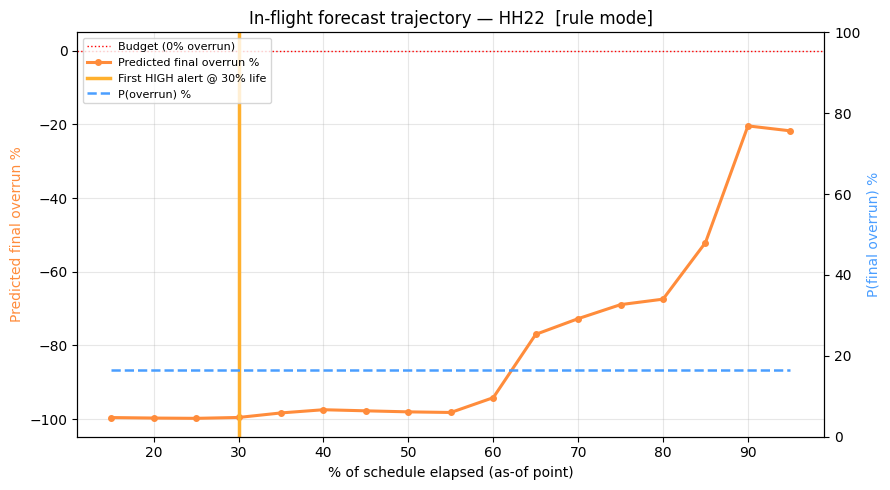

In [13]:
# ============================================================================
#  §10 · IN-FLIGHT OVERRUN FORECASTER   (predicts BEFORE a project completes)
# ----------------------------------------------------------------------------
#  Goal: score a project that is still RUNNING — estimate its final overrun and
#  surface areas of concern (labor / material / schedule / volatility) before the
#  budget is actually breached.
#
#  WHY THIS IS A SEPARATE MODEL FROM §6/§7
#  §6/§7 use post-hoc features (actual÷planned ratios, late_stage_share, ...) that
#  only exist once a project is finished — useless for an in-progress job. This
#  module is built to be LEAKAGE-SAFE: every feature it uses is knowable at the
#  reporting date, never after it.
#
#  TWO LAYERS
#   • Day-0 prior  — static plan/BOM/routing features only. A risk read available
#                    before any money is spent.
#   • In-flight    — spend-to-date vs the planned S-curve (EVM): % budget consumed,
#                    overrun index, projected EAC, labor/material divergence,
#                    burn volatility — all computed from data up to the as-of date.
#
#  HOW IT TRAINS WITHOUT LEAKAGE
#   Each COMPLETED historical project is "replayed": we take snapshots at 20%,30%,
#   …,90% of its schedule, compute only the to-date features at each snapshot, and
#   label every snapshot with that project's FINAL outcome. Pooling those snapshots
#   teaches the model "given what a project looks like X% of the way in, how does it
#   end?" Validation is leave-one-PROJECT-out so snapshots from the same project
#   never sit in both train and test.
#
#  WORKS NOW (N=2): runs in transparent RULE mode (EVM projection + day-0 prior).
#  Add the 13 projects in §3, re-run §4, then run this — it auto-switches to a
#  FITTED classifier+regressor with leave-one-project-out validation.
#
#  USAGE
#   BUNDLE = train_forecaster()                 # fit (or rule fallback)
#   forecast_report("HH22", asof_frac=0.55, bundle=BUNDLE)        # registered proj
#   plot_forecast_trajectory("HH22", bundle=BUNDLE)               # convergence plot
#   # brand-new in-progress project not in the registry:
#   forecast_report(costs=my_costs_df, budget=1_200_000,
#                   pl_lab=..., pl_mat=..., pl_hrs=...,
#                   static=dict(n_route_ops=8,bom_lines=33,energetic_lines=11,
#                               authorized_qty=5000,contract_type="F"),
#                   asof_date="2026-03-01", bundle=BUNDLE)
# ============================================================================
import numpy as np, pandas as pd, math, warnings
warnings.filterwarnings("ignore")

# ---- value column from the COSTS files, and the KNOWN export de-dup factor -----
# The raw *_COSTS exports double-count (sum to exactly 2.000x the authoritative
# actual). §4 fixed this by scaling to the FINAL actual — but that scale embeds the
# final actual and would LEAK it into a to-date snapshot. So in-flight we divide raw
# postings by this documented constant instead. Set to 1.0 if a project's export is clean.
VAL_COL      = "Val/COArea Crcy"
DEDUP_FACTOR = 2.0

CHECKPOINTS  = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
MIN_PROJECTS, MIN_PER_CLASS = 10, 3      # gate to attempt a fitted model

STATIC_FEATS = ["lead_n_route_ops","lead_bom_lines","lead_energetic_lines",
                "lead_authorized_qty","lead_contract_nonfirm","lead_planned_rate",
                "lead_planned_mat_share","lead_planned_lab_share","lead_log_budget"]
INFLIGHT_FEATS = ["pct_sched","pct_budget","overrun_index","eac_ratio",
                  "labor_vs_plan","material_vs_plan","burn_cv_todate","budget_minus_sched"]
ALL_FEATS = STATIC_FEATS + INFLIGHT_FEATS


# ----------------------------------------------------------------------------
# Plan + static leading features  (everything here is knowable at project start)
# ----------------------------------------------------------------------------
def _plan_for(key):
    """Return planned $ / hours for a registered project from the overview file."""
    ov = load_overview()                       # defined in §4
    spec = next(p for p in PROJECTS if p.key == key)
    o = overview_row(ov, spec)
    return dict(budget=float(o["Release Budget"]),
                pl_lab=float(o["Fnd Pln Cst-Lab"]), pl_mat=float(o["Fnd Pln Cst-Mat"]),
                pl_hrs=float(o["Plan Hours"]), auth_qty=float(o["Authorized Qty"]),
                contract_type=spec.contract_type, n_route_ops=spec.n_route_ops)

def static_leading_features(key=None, plan=None, static=None):
    """Day-0 feature vector. For registered projects read FEATURES + plan; for a new
    project pass plan(dict) + static(dict)."""
    if key is not None and key in FEATURES.index:
        fr = FEATURES.loc[key]
        n_ops   = float(fr["n_route_ops"]); bom = float(fr["bom_lines"])
        energ   = float(fr["energetic_lines"]); auth = float(fr["authorized_qty"])
        ctype   = str(fr["contract_type"]); prate = float(fr["planned_rate"])
        budget  = float(plan["budget"]); pl_lab = float(plan["pl_lab"]); pl_mat = float(plan["pl_mat"])
    else:
        s = static or {}
        n_ops = float(s.get("n_route_ops", 0)); bom = float(s.get("bom_lines", 0))
        energ = float(s.get("energetic_lines", 0)); auth = float(s.get("authorized_qty", 0))
        ctype = str(s.get("contract_type", "F"))
        budget = float(plan["budget"]); pl_lab = float(plan["pl_lab"])
        pl_mat = float(plan["pl_mat"]); pl_hrs = float(plan.get("pl_hrs", 0)) or 1.0
        prate = pl_lab / pl_hrs if pl_hrs else 0.0
    return {
        "lead_n_route_ops": n_ops, "lead_bom_lines": bom, "lead_energetic_lines": energ,
        "lead_authorized_qty": auth, "lead_contract_nonfirm": 0.0 if ctype == "F" else 1.0,
        "lead_planned_rate": prate,
        "lead_planned_mat_share": pl_mat / budget if budget else 0.0,
        "lead_planned_lab_share": pl_lab / budget if budget else 0.0,
        "lead_log_budget": math.log10(budget) if budget > 0 else 0.0,
    }

def _ramp(x, lo, hi):
    if x is None or (isinstance(x, float) and math.isnan(x)): return 0.0
    return float(np.clip((x - lo) / (hi - lo), 0, 1))

def day0_prior(lead):
    """Transparent 0..1 'before-it-starts' risk from leading features only."""
    parts = [_ramp(lead["lead_energetic_lines"], 3, 15),
             _ramp(lead["lead_bom_lines"], 10, 40),
             _ramp(lead["lead_n_route_ops"], 4, 12),
             _ramp(lead["lead_planned_mat_share"], 0.20, 0.60),  # material-heavy plans run hot (cf. WG22)
             0.6 if lead["lead_contract_nonfirm"] else 0.2]
    return float(np.mean(parts))


# ----------------------------------------------------------------------------
# In-flight snapshot  (uses ONLY postings up to the as-of date)
# ----------------------------------------------------------------------------
def inflight_snapshot(costs, budget, plan, asof_frac=None, asof_date=None):
    """Leakage-safe to-date features at a point in the schedule.
       costs must have VAL_COL, a 'date' column, and a 'bucket' column."""
    c = costs.dropna(subset=["date"]).sort_values("date").copy()
    c["raw"] = pd.to_numeric(c[VAL_COL], errors="coerce") / DEDUP_FACTOR
    t0, t1 = c["date"].min(), c["date"].max()
    span = max((t1 - t0).days, 1)
    if asof_date is not None:
        cutoff = pd.to_datetime(asof_date); f = np.clip((cutoff - t0).days / span, 0, 1)
    else:
        f = float(np.clip(asof_frac, 1e-3, 1.0)); cutoff = t0 + pd.Timedelta(days=f * span)

    td = c[c["date"] <= cutoff]
    cum   = td["raw"].sum()
    lab   = td.loc[td["bucket"].isin(["labor_reg", "labor_ot"]), "raw"].sum()
    mat   = td.loc[td["bucket"] == "material", "raw"].sum()
    pc    = float(np.clip(planned_scurve(f), 1e-3, 1.0))          # planned % complete (§5 S-curve)
    eac   = cum / pc
    monthly = td.set_index("date")["raw"].resample("MS").sum()
    cv    = float(monthly.std() / monthly.mean()) if monthly.mean() else 0.0

    pl_lab, pl_mat = float(plan["pl_lab"]), float(plan["pl_mat"])
    return {
        "pct_sched": f, "pct_budget": cum / budget if budget else 0.0,
        "overrun_index": (cum / budget) / max(f, 1e-3) if budget else 0.0,
        "eac_ratio": eac / budget if budget else 0.0,
        "labor_vs_plan": lab / max(pl_lab * pc, 1e-9),       # to-date labor vs planned-to-date labor
        "material_vs_plan": mat / max(pl_mat * pc, 1e-9),    # to-date material vs planned-to-date material
        "burn_cv_todate": cv,
        "budget_minus_sched": (cum / budget if budget else 0.0) - f,
        "_eac_dollars": eac, "_cum": cum, "_asof_date": str(cutoff.date()),
    }


# ----------------------------------------------------------------------------
# Areas of concern  (the "before it overruns" alarms — all leakage-safe)
# ----------------------------------------------------------------------------
def _sev(x, watch, high, crit):
    return "critical" if x >= crit else "high" if x >= high else "watch" if x >= watch else None

def concern_flags(snap):
    flags = []
    def add(area, sev, msg):
        if sev: flags.append({"area": area, "severity": sev, "message": msg})
    add("Schedule",  _sev(snap["overrun_index"], 1.05, 1.15, 1.30),
        f"Spending ahead of schedule (overrun index {snap['overrun_index']:.2f})")
    add("Forecast",  _sev(snap["eac_ratio"], 1.05, 1.10, 1.20),
        f"Projected to finish at {(snap['eac_ratio']-1)*100:+.0f}% vs budget")
    add("Labor",     _sev(snap["labor_vs_plan"], 1.10, 1.25, 1.50),
        f"Labor running {snap['labor_vs_plan']:.2f}x its planned-to-date pace")
    add("Material",  _sev(snap["material_vs_plan"], 1.10, 1.25, 1.50),
        f"Material running {snap['material_vs_plan']:.2f}x its planned-to-date pace")
    add("Volatility",_sev(snap["burn_cv_todate"], 1.5, 2.0, 3.0),
        f"Lumpy / volatile burn (CV {snap['burn_cv_todate']:.2f})")
    add("Pace",      _sev(snap["budget_minus_sched"], 0.15, 0.25, 0.40),
        f"{snap['pct_budget']*100:.0f}% of budget spent at {snap['pct_sched']*100:.0f}% of schedule")
    return flags

def watch_level(snap, flags, prob):
    sevs = {f["severity"] for f in flags}
    if "critical" in sevs or snap["eac_ratio"] >= 1.20 or prob >= 0.80: return "CRITICAL"
    if "high" in sevs or snap["eac_ratio"] >= 1.08 or prob >= 0.60:     return "HIGH"
    if flags or prob >= 0.40:                                           return "WATCH"
    return "LOW"


# ----------------------------------------------------------------------------
# Training set: replay every completed project into leakage-safe snapshots
# ----------------------------------------------------------------------------
def build_training_snapshots():
    rows = []
    for spec in PROJECTS:
        key = spec.key
        if key not in RAW:        # need the cost time-series
            continue
        d = RAW[key]; costs = d["costs"]; budget = float(d["budget"]); actual = float(d["actual"])
        plan = _plan_for(key)
        lead = static_leading_features(key, plan=plan)
        overran = int(actual > budget); overrun_pct = (actual / budget - 1) * 100
        for f in CHECKPOINTS:
            snap = inflight_snapshot(costs, budget, plan, asof_frac=f)
            row = {**lead, **{k: v for k, v in snap.items() if not k.startswith("_")}}
            row.update(project=key, overran=overran, overrun_pct=overrun_pct, asof_frac=f)
            rows.append(row)
    return pd.DataFrame(rows)


# ----------------------------------------------------------------------------
# Train (fitted if enough projects, else transparent rule mode)
# ----------------------------------------------------------------------------
def train_forecaster(verbose=True):
    snaps = build_training_snapshots()
    n_proj = snaps["project"].nunique() if len(snaps) else 0
    classes = snaps["overran"].nunique() if len(snaps) else 0
    per_class_ok = (snaps.groupby("overran")["project"].nunique().min()
                    if len(snaps) and classes == 2 else 0)
    can_fit = (n_proj >= MIN_PROJECTS and classes == 2 and per_class_ok >= MIN_PER_CLASS)

    bundle = {"mode": "rule", "feats": ALL_FEATS, "snaps": snaps,
              "plans": {p.key: _plan_for(p.key) for p in PROJECTS if p.key in RAW}}

    if not can_fit:
        if verbose:
            print("="*74)
            print(f"RULE MODE — projects={n_proj}, classes={classes}, smaller-class projects={per_class_ok}.")
            print("Forecasts use the EVM projection + day-0 prior (transparent, no fit).")
            print(f"Add projects in §3 (need >= {MIN_PROJECTS} with both outcomes, "
                  f">= {MIN_PER_CLASS} per class) to unlock the fitted model.")
            print("="*74)
        return bundle

    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression
    from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
    from sklearn.model_selection import GroupKFold
    from sklearn.metrics import accuracy_score, roc_auc_score, mean_absolute_error

    X = snaps[ALL_FEATS].fillna(0.0).values
    y = snaps["overran"].astype(int).values
    ypct = snaps["overrun_pct"].values
    groups = snaps["project"].values

    scaler = StandardScaler().fit(X); Xs = scaler.transform(X)
    clf = GradientBoostingClassifier(random_state=0).fit(X, y)
    reg = GradientBoostingRegressor(random_state=0).fit(X, ypct)
    logit = LogisticRegression(max_iter=2000).fit(Xs, y)

    # leave-one-PROJECT-out validation (snapshots grouped by project)
    gkf = GroupKFold(n_splits=min(n_proj, 5))
    acc, auc, mae = [], [], []
    for tr, te in gkf.split(X, y, groups):
        c = GradientBoostingClassifier(random_state=0).fit(X[tr], y[tr])
        r = GradientBoostingRegressor(random_state=0).fit(X[tr], ypct[tr])
        p = c.predict(X[te])
        acc.append(accuracy_score(y[te], p))
        if len(set(y[te])) == 2:
            auc.append(roc_auc_score(y[te], c.predict_proba(X[te])[:, 1]))
        mae.append(mean_absolute_error(ypct[te], r.predict(X[te])))

    imp = (pd.Series(clf.feature_importances_, index=ALL_FEATS)
             .sort_values(ascending=False))
    bundle.update(mode="fitted", scaler=scaler, clf=clf, reg=reg, logit=logit, importance=imp)
    if verbose:
        print("="*74)
        print(f"FITTED MODE — {len(snaps)} snapshots from {n_proj} projects "
              f"({(y==1).sum()} overrun / {(y==0).sum()} on-budget rows).")
        print(f"Leave-one-project-out: accuracy {np.mean(acc):.0%}"
              + (f" · AUC {np.mean(auc):.2f}" if auc else "")
              + f" · final-overrun MAE {np.mean(mae):.1f} pts")
        print("\nTop in-flight predictors (gradient-boosting importance):")
        print(imp.head(8).to_string())
        if n_proj < 40:
            print("\n  ⚠ Small sample: these importances/metrics are indicative, not settled —"
                  "\n    expect them to shift as more projects are added. Treat as directional.")
        print("="*74)
    return bundle


# ----------------------------------------------------------------------------
# Predict a single project AS OF a point in its (unfinished) schedule
# ----------------------------------------------------------------------------
def forecast(key=None, asof_frac=0.5, asof_date=None, bundle=None,
             costs=None, budget=None, pl_lab=None, pl_mat=None, pl_hrs=None, static=None):
    bundle = bundle or train_forecaster(verbose=False)
    if key is not None:
        plan = bundle["plans"].get(key) or _plan_for(key)
        costs = RAW[key]["costs"]; budget = plan["budget"]
        lead  = static_leading_features(key, plan=plan)
        label = key
    else:
        plan = dict(budget=float(budget), pl_lab=float(pl_lab),
                    pl_mat=float(pl_mat), pl_hrs=float(pl_hrs or 1.0))
        lead  = static_leading_features(plan=plan, static=static)
        label = (static or {}).get("name", "NEW PROJECT")

    snap = inflight_snapshot(costs, budget, plan, asof_frac=asof_frac, asof_date=asof_date)
    feat = {**lead, **{k: v for k, v in snap.items() if not k.startswith("_")}}
    prior = day0_prior(lead)

    if bundle["mode"] == "fitted":
        x = np.array([[feat[c] for c in ALL_FEATS]], dtype=float)
        prob = float(bundle["clf"].predict_proba(x)[0, 1])
        pred_pct = float(bundle["reg"].predict(x)[0])
    else:
        # transparent rule: EVM projection for magnitude; prob from EAC blended w/ day-0 prior
        pred_pct = (snap["eac_ratio"] - 1) * 100
        evm_p = float(np.clip((snap["eac_ratio"] - 0.97) / 0.20, 0, 1))
        prob  = float(np.clip(0.65 * evm_p + 0.35 * prior, 0, 1))

    flags = concern_flags(snap)
    has_strong = any(f["severity"] in ("high", "critical") for f in flags)
    # When risk is driven by the model/profile but the CURRENT trajectory hasn't
    # visibly diverged yet, say so explicitly — never report a high watch level
    # with "no concerns". This is the leading-indicator value-add over plain EVM.
    if bundle["mode"] == "fitted" and prob >= 0.55 and not has_strong:
        sev = "critical" if prob >= 0.80 else "high" if prob >= 0.65 else "watch"
        flags.append({"area": "Profile", "severity": sev,
            "message": f"Model projects {pred_pct:+.0f}% final overrun from project profile + "
                       f"early trajectory (current spend still tracking plan)"})
    if bundle["mode"] == "rule" and prior >= 0.50 and snap["eac_ratio"] < 1.05 and snap["pct_sched"] < 0.60:
        flags.append({"area": "Profile", "severity": "watch",
            "message": f"Day-0 profile risk elevated ({prior*100:.0f}/100); EVM trajectory not yet conclusive"})

    level = watch_level(snap, flags, prob)
    note = ("Early stage — forecast is low-confidence until more of the schedule elapses"
            if snap["pct_sched"] < 0.35 else "")
    return {
        "label": label, "mode": bundle["mode"], "asof": snap["_asof_date"],
        "pct_schedule": snap["pct_sched"], "pct_budget": snap["pct_budget"],
        "day0_prior": prior, "prob_overrun": prob,
        "predicted_final_overrun_pct": pred_pct,
        "evm_projected_eac": snap["_eac_dollars"], "budget": budget,
        "watch_level": level, "concerns": flags, "note": note, "snap": snap,
    }


# ----------------------------------------------------------------------------
# Readable report
# ----------------------------------------------------------------------------
def forecast_report(*args, **kwargs):
    r = forecast(*args, **kwargs)
    bar = {"LOW": "·", "WATCH": "▲", "HIGH": "▲▲", "CRITICAL": "■■■"}[r["watch_level"]]
    print(f"\n┏━ IN-FLIGHT FORECAST · {r['label']}   [{r['mode'].upper()} MODE]")
    print(f"┃  As of {r['asof']}  —  {r['pct_schedule']*100:.0f}% of schedule, "
          f"{r['pct_budget']*100:.0f}% of budget spent")
    print(f"┃  Day-0 prior risk ........ {r['day0_prior']*100:.0f}/100")
    print(f"┃  P(final overrun) ........ {r['prob_overrun']*100:.0f}%")
    print(f"┃  Predicted final overrun . {r['predicted_final_overrun_pct']:+.0f}%  "
          f"(EVM EAC ≈ ${r['evm_projected_eac']:,.0f} vs ${r['budget']:,.0f} budget)")
    print(f"┃  WATCH LEVEL ............. {bar} {r['watch_level']}")
    if r["concerns"]:
        print("┃  Areas of concern:")
        for f in r["concerns"]:
            print(f"┃    [{f['severity'].upper():8s}] {f['area']:10s} {f['message']}")
    else:
        print("┃  No areas of concern at this checkpoint.")
    if r["note"]:
        print(f"┃  Note: {r['note']}")
    print("┗" + "━"*60)
    return r


# ----------------------------------------------------------------------------
# Trajectory plot: how the forecast evolves as the project runs
# ----------------------------------------------------------------------------
def plot_forecast_trajectory(key=None, bundle=None, asof_frac=0.95, **kw):
    import matplotlib.pyplot as plt
    bundle = bundle or train_forecaster(verbose=False)
    grid = [f for f in np.round(np.arange(0.15, asof_frac + 1e-9, 0.05), 2)]
    preds, probs, first_flag = [], [], None
    for f in grid:
        r = forecast(key=key, asof_frac=f, bundle=bundle, **kw)
        preds.append(r["predicted_final_overrun_pct"]); probs.append(r["prob_overrun"]*100)
        if first_flag is None and r["watch_level"] in ("HIGH", "CRITICAL"):
            first_flag = f
    fig, ax1 = plt.subplots(figsize=(9, 5))
    x = [g*100 for g in grid]
    ax1.axhline(0, color="red", ls=":", lw=1, label="Budget (0% overrun)")
    ax1.plot(x, preds, "-o", color="#ff8c3b", lw=2.2, ms=4, label="Predicted final overrun %")
    ax1.set_xlabel("% of schedule elapsed (as-of point)")
    ax1.set_ylabel("Predicted final overrun %", color="#ff8c3b")
    ax2 = ax1.twinx()
    ax2.plot(x, probs, "--", color="#4a9eff", lw=1.8, label="P(overrun) %")
    ax2.set_ylabel("P(final overrun) %", color="#4a9eff"); ax2.set_ylim(0, 100)
    if first_flag is not None:
        ax1.axvline(first_flag*100, color="#ffb02e", lw=2.5,
                    label=f"First HIGH alert @ {first_flag*100:.0f}% life")
    ttl = key or (kw.get("static", {}) or {}).get("name", "project")
    ax1.set_title(f"In-flight forecast trajectory — {ttl}  [{bundle['mode']} mode]")
    ax1.grid(alpha=0.3)
    l1, lab1 = ax1.get_legend_handles_labels(); l2, lab2 = ax2.get_legend_handles_labels()
    ax1.legend(l1+l2, lab1+lab2, fontsize=8, loc="upper left")
    plt.tight_layout(); plt.show()


# ----------------------------------------------------------------------------
# Demo on whatever is registered (rule mode now; fitted once 15 projects loaded)
# ----------------------------------------------------------------------------
def run_inflight_demo(asof_frac=0.55):
    BUNDLE = train_forecaster(verbose=True)
    for spec in PROJECTS:
        if spec.key in RAW:
            forecast_report(key=spec.key, asof_frac=asof_frac, bundle=BUNDLE)
    # trajectory for the first project as an example
    first = next((p.key for p in PROJECTS if p.key in RAW), None)
    if first:
        plot_forecast_trajectory(key=first, bundle=BUNDLE)
    return BUNDLE

# Run it:
BUNDLE = run_inflight_demo(asof_frac=0.55)



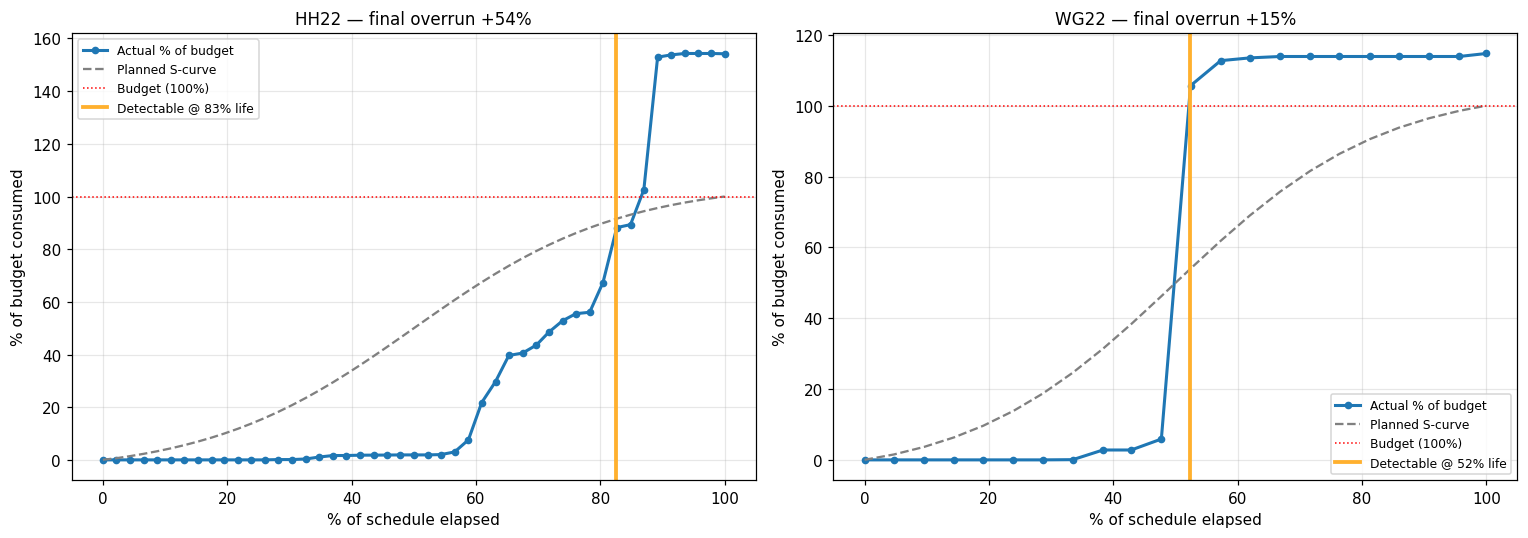
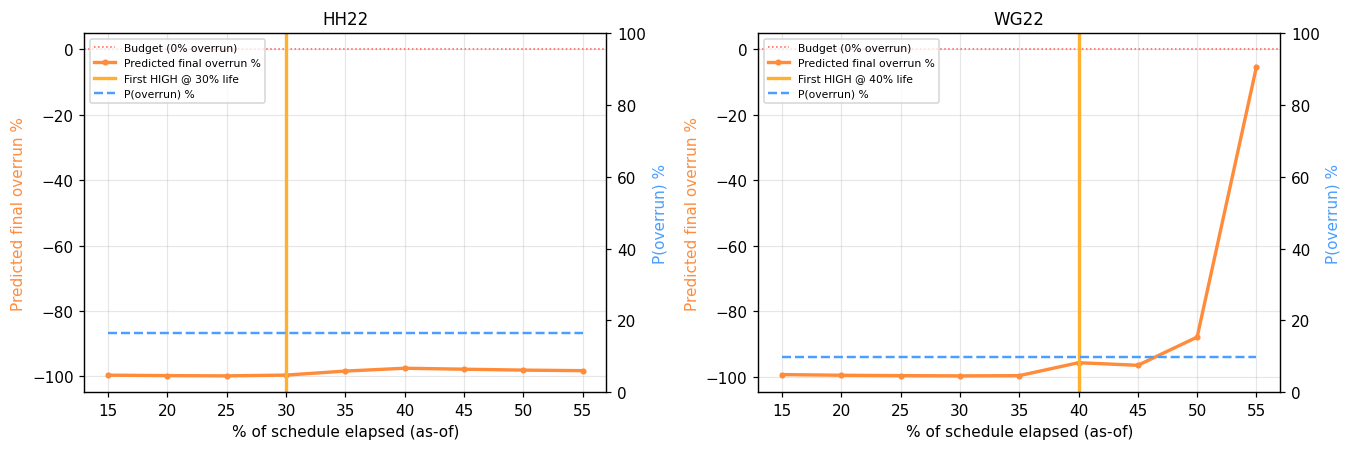


Saved dashboard -> caaa_dashboard.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'caaa_dashboard.html'

In [14]:
# ============================================================================
#  §9 · ONE-PAGE DASHBOARD   (paste as a new cell AFTER §7; run top-to-bottom first)
#  Uses live notebook objects: FEATURES, RISK_REGISTER, ew_summary, EW,
#  INDICATORS, score_project, PROJECTS.  Renders inline + saves + downloads HTML.
#  It is fully dynamic: register more projects in §3 and re-run — the dashboard grows.
#
#  IN-FLIGHT FORECAST PANEL (optional): if the §10 forecaster cell has been run
#  (so `forecast` / `train_forecaster` / `BUNDLE` exist), the dashboard adds a live
#  panel that scores each project as if still running — watch level, predicted final
#  overrun, P(overrun), areas of concern, and a forecast-trajectory chart. If §10
#  hasn't been run, the dashboard still builds and just notes the panel is available.
#  Control the as-of checkpoint with build_dashboard(asof_frac=0.55).
# ============================================================================
import io, base64, html as _html
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import HTML, display

TIER_COLORS  = {"Low":"#2dd4a7","Moderate":"#ffd23f","High":"#ff8c3b","Critical":"#ff5b52"}
WATCH_COLORS = {"LOW":"#2dd4a7","WATCH":"#ffd23f","HIGH":"#ff8c3b","CRITICAL":"#ff5b52"}
SEV_COLORS   = {"watch":"#ffd23f","high":"#ff8c3b","critical":"#ff5b52"}
_SEV_RANK    = {"LOW":0,"WATCH":1,"HIGH":2,"CRITICAL":3}

def _fig_to_b64():
    """Regenerate the burn-curve panel from the live EW results and return base64 PNG."""
    keys = list(EW.keys())
    fig, axes = plt.subplots(1, len(keys), figsize=(7*len(keys), 5), squeeze=False)
    for ax, k in zip(axes[0], keys):
        res, summ = EW[k]
        ax.plot(res["sched_pct"]*100, res["pct_budget"]*100, "-o", lw=2, ms=4,
                color="#1f77b4", label="Actual % of budget")
        ax.plot(res["sched_pct"]*100, res["planned_complete"]*100, "--",
                color="gray", label="Planned S-curve")
        ax.axhline(100, color="red", ls=":", lw=1, label="Budget (100%)")
        if summ["detect_lifecycle_pct"] is not None:
            ax.axvline(summ["detect_lifecycle_pct"], color="#ffb02e", lw=2.5,
                       label=f"Detectable @ {summ['detect_lifecycle_pct']:.0f}% life")
        ax.set_title(f"{k} — final overrun {summ['final_overrun_pct']:+.0f}%", fontsize=11)
        ax.set_xlabel("% of schedule elapsed"); ax.set_ylabel("% of budget consumed")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode()

def _money(x):
    x = float(x)
    return f"${x/1e6:.2f}M" if abs(x) >= 1e6 else f"${x:,.0f}"

def _e(s): return _html.escape(str(s))

# ---------------------------------------------------------------------------
#  IN-FLIGHT FORECASTER INTEGRATION (optional — needs the §10 cell)
# ---------------------------------------------------------------------------
def _forecaster_available():
    G = globals()
    return all(n in G for n in ("forecast", "train_forecaster"))

def _get_bundle():
    G = globals()
    b = G.get("BUNDLE")
    if not (isinstance(b, dict) and "mode" in b):
        b = G["train_forecaster"](verbose=False)
    return b

def _live_keys():
    """Registered projects that have a cost time-series the forecaster can read."""
    G = globals(); raw = G.get("RAW", {})
    return [p.key for p in PROJECTS if p.key in raw]

def _forecast_traj_b64(bundle, keys, asof_frac):
    """Forecast-trajectory subplots: predicted final overrun % and P(overrun) vs as-of point."""
    G = globals()
    grid = [round(float(x), 2) for x in np.arange(0.15, min(asof_frac, 0.95) + 1e-9, 0.05)]
    fig, axes = plt.subplots(1, len(keys), figsize=(6.2*len(keys), 4.2), squeeze=False)
    for ax, k in zip(axes[0], keys):
        preds, probs, first = [], [], None
        for fr in grid:
            r = G["forecast"](key=k, asof_frac=fr, bundle=bundle)
            preds.append(r["predicted_final_overrun_pct"]); probs.append(r["prob_overrun"]*100)
            if first is None and r["watch_level"] in ("HIGH", "CRITICAL"): first = fr
        x = [g*100 for g in grid]
        ax.axhline(0, color="#ff5b52", ls=":", lw=1, label="Budget (0% overrun)")
        ax.plot(x, preds, "-o", color="#ff8c3b", lw=2.2, ms=3, label="Predicted final overrun %")
        ax2 = ax.twinx(); ax2.plot(x, probs, "--", color="#4a9eff", lw=1.6, label="P(overrun) %")
        ax2.set_ylim(0, 100); ax2.set_ylabel("P(overrun) %", color="#4a9eff")
        if first is not None:
            ax.axvline(first*100, color="#ffb02e", lw=2.2, label=f"First HIGH @ {first*100:.0f}% life")
        ax.set_title(str(k), fontsize=11); ax.set_xlabel("% of schedule elapsed (as-of)")
        ax.set_ylabel("Predicted final overrun %", color="#ff8c3b"); ax.grid(alpha=0.3)
        h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1+h2, l1+l2, fontsize=7, loc="upper left")
    plt.tight_layout()
    buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=110, bbox_inches="tight"); plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode()

def _inflight_cards(fc):
    """fc: dict key -> forecast() result. Worst watch level first."""
    cards = ""
    for k in sorted(fc, key=lambda kk: -_SEV_RANK.get(fc[kk]["watch_level"], 0)):
        r = fc[k]; wl = r["watch_level"]; col = WATCH_COLORS.get(wl, "#ffd23f")
        desc = _e(FEATURES.loc[k, "description"]) if k in FEATURES.index else ""
        crows = ""
        for c in r["concerns"]:
            sc = SEV_COLORS.get(c["severity"], "#ffd23f")
            crows += (f'<div class="concern"><span class="csev" style="background:{sc}22;color:{sc};'
                      f'border:1px solid {sc}">{_e(c["area"])}</span>'
                      f'<span class="cmsg">{_e(c["message"])}</span></div>')
        if not crows:
            crows = '<div class="concern"><span class="cmsg" style="color:var(--mut)">No areas of concern at this checkpoint.</span></div>'
        if r.get("note"):
            crows += f'<div class="concern"><span class="cmsg cnote">{_e(r["note"])}</span></div>'
        pred_col = "#ff5b52" if r["predicted_final_overrun_pct"] > 5 else ("#2dd4a7" if r["predicted_final_overrun_pct"] < 0 else "#ffd23f")
        cards += f"""
        <div class="card rise">
          <div class="top">
            <div><div class="code">{_e(k)}</div><div class="desc">{desc}</div>
              <div class="status">AS OF {r['pct_schedule']*100:.0f}% SCHEDULE · {r['pct_budget']*100:.0f}% BUDGET SPENT</div></div>
            <div class="tier" style="background:{col}22;color:{col};border:1px solid {col}">{_e(wl)}</div>
          </div>
          <div class="grid3">
            <div class="cell"><div class="k">Day-0 Prior</div><div class="v">{r['day0_prior']*100:.0f}<span style="font-size:14px;color:var(--mut)">/100</span></div></div>
            <div class="cell"><div class="k">P(overrun)</div><div class="v">{r['prob_overrun']*100:.0f}%</div></div>
            <div class="cell"><div class="k">Pred. Final Overrun</div><div class="v big" style="color:{pred_col}">{r['predicted_final_overrun_pct']:+.0f}%</div></div>
          </div>
          <div class="detect"><span class="dot" style="background:{col};box-shadow:0 0 9px {col}"></span>
            <span>EVM projected EAC ≈ <b style="color:var(--ink)">${r['evm_projected_eac']:,.0f}</b> vs ${r['budget']:,.0f} budget</span></div>
          <div class="concerns">{crows}</div>
        </div>"""
    return cards

def _build_inflight_section(bundle, asof_frac):
    keys = _live_keys()
    G = globals()
    fc = {}
    for k in keys:
        try:
            fc[k] = G["forecast"](key=k, asof_frac=asof_frac, bundle=bundle)
        except Exception as ex:
            print(f"  (forecast skipped for {k}: {ex})")
    if not fc:
        return "", "rule"
    fmode = bundle.get("mode", "rule")
    traj = _forecast_traj_b64(bundle, list(fc.keys()), asof_frac)
    section = f"""
  <div class="sec rise"><span class="n">LIVE</span><h2>In-Flight Forecast</h2>
    <span class="tag">as of {asof_frac*100:.0f}% schedule · {_e(fmode)} mode</span></div>
  <div class="alert rise" style="border-color:var(--amber-dim);border-left-color:var(--amber);
       background:linear-gradient(135deg,rgba(255,176,46,.10),rgba(74,158,255,.05))">
    <div class="lab" style="color:var(--amber)">◆ Predicting before completion</div>
    <h3 style="color:#fff">Scoring each project as if it were still running</h3>
    <p>Uses only what is knowable at the as-of date — day-0 plan / BOM / routing features plus spend-to-date
       against the planned S-curve (no post-hoc actuals). It forecasts the final overrun and flags
       <b style="color:#fff">where</b> the risk is building <b style="color:#fff">before</b> the budget is breached.</p>
  </div>
  <div class="cards">{_inflight_cards(fc)}</div>
  <div class="chartbox rise" style="margin-top:18px"><img src="data:image/png;base64,{traj}" alt="forecast trajectories">
    <div class="chartcap">Forecast trajectory — how the predicted final overrun (orange) and probability of overrun
      (blue dashed) evolve as each project runs; the amber line marks the first checkpoint the watch level reaches
      HIGH or CRITICAL. A back-loaded project can look benign to plain EVM yet be flagged earlier from its profile.</div></div>"""
    return section, fmode

def build_dashboard(save_path="caaa_dashboard.html", do_download=True, asof_frac=0.55):
    n_proj  = len(FEATURES)
    classes = FEATURES["overran"].nunique()
    model_status = (f"EXPERT-WEIGHTED (N={n_proj}, single outcome class)"
                    if (n_proj < 15 or classes < 2)
                    else f"FITTED CLASSIFIER (N={n_proj})")

    # ---- in-flight forecaster panel (optional; needs the §10 cell) ----
    inflight_section, forecaster_badge, note_extra = "", "", ""
    if _forecaster_available():
        try:
            bundle = _get_bundle()
            inflight_section, fmode = _build_inflight_section(bundle, asof_frac)
            n_live = len(_live_keys())
            forecaster_badge = (f'<span class="badge" style="border-color:var(--amber);color:var(--amber)">'
                                f'FORECASTER · {fmode.upper()} (N={n_live})</span>')
            note_extra = (" An <b>in-flight forecaster</b> (§10) extends this to running projects using only "
                          "leakage-safe leading + spend-to-date features, trained by replaying completed projects "
                          "into time-sliced snapshots and validated leave-one-project-out.")
        except Exception as ex:
            inflight_section = (f'<div class="note rise">In-flight forecaster present but could not run '
                                f'({_e(ex)}). Re-run §10, then this cell.</div>')
    else:
        inflight_section = ('<div class="sec rise"><span class="n">LIVE</span><h2>In-Flight Forecast</h2></div>'
                            '<div class="note rise">Run the <b>§10 in-flight forecaster</b> cell first, then re-run '
                            'this dashboard to populate the live forecast panel (watch levels, predicted overrun, '
                            'areas of concern, and trajectory chart).</div>')

    # ---- headline labor/material split (descriptive) ----
    f = FEATURES.copy()
    worst_labor = f["labor_cost_ratio"].idxmax()
    worst_mat   = f["material_cost_ratio"].idxmax()

    # ---- project cards ----
    cards = ""
    for k in RISK_REGISTER.index:
        rr, fr = RISK_REGISTER.loc[k], FEATURES.loc[k]
        ew = ew_summary.loc[k]
        tier = rr["tier"]; col = TIER_COLORS.get(tier, "#ffd23f")
        det = (f"detectable @ <b>{ew['detect_lifecycle_pct']:.1f}%</b> of lifecycle "
               f"({ew['detect_month']})" if pd.notna(ew['detect_lifecycle_pct'])
               else "<b>not yet detectable</b> by the rule")
        cards += f"""
        <div class="card rise">
          <div class="top">
            <div><div class="code">{_e(k)}</div>
                 <div class="desc">{_e(rr['description'])}</div>
                 <div class="status">STATUS: {_e(fr.get('status','—'))} · {int(ew['n_months'])} MONTHS OF POSTINGS</div></div>
            <div class="tier" style="background:{col}22;color:{col};border:1px solid {col}">{_e(tier).upper()} RISK</div>
          </div>
          <div class="grid3">
            <div class="cell"><div class="k">Release Budget</div><div class="v">{_money(fr['budget'])}</div></div>
            <div class="cell"><div class="k">Actual Cost</div><div class="v">{_money(fr['actual'])}</div></div>
            <div class="cell"><div class="k">Overrun</div><div class="v big" style="color:{col}">{fr['overrun_pct']:+.0f}%</div></div>
          </div>
          <div class="meter">
            <div class="lab"><span class="t">Composite Risk Score</span><span class="s">{rr['risk_score']:.1f}<span class="den">/100</span></span></div>
            <div class="meterbox"><div class="track"></div>
              <div class="needle" style="left:calc({min(rr['risk_score'],100)}% - 1.5px)"></div></div>
            <div class="zones"><span>0 LOW</span><span>25 MOD</span><span>50 HIGH</span><span>75 CRIT</span><span>100</span></div>
          </div>
          <div class="detect"><span class="dot"></span><span>Overrun {det}.</span></div>
        </div>"""

    # ---- family bars ----
    fam_defs = [("Workforce","f_workforce",INDICATORS["workforce"][0]),
                ("Cost Trend / Exec","f_cost_trend",INDICATORS["cost_trend"][0]),
                ("Complexity","f_complexity",INDICATORS["complexity"][0]),
                ("Contract / Prog.","f_contract",INDICATORS["contract"][0])]
    fam_rows = ""
    for label, colname, w in fam_defs:
        bars = ""
        for k in RISK_REGISTER.index:
            v = float(RISK_REGISTER.loc[k, colname])
            bc = "#ff5b52" if v>=75 else "#ff8c3b" if v>=50 else "#ffd23f" if v>=25 else "#2dd4a7"
            bars += (f'<div class="barline"><span class="tagk">{_e(k)}</span>'
                     f'<div class="bartrack"><div class="barfill" style="width:{max(v,4)}%;background:{bc}">{v:.0f}</div></div></div>')
        fam_rows += (f'<div class="famrow"><div class="name">{label} <span class="w">· w {w:.2f}</span></div>'
                     f'<div class="bars">{bars}</div></div>')

    # ---- early-warning table ----
    ew_rows = ""
    for k in ew_summary.index:
        s = ew_summary.loc[k]
        ew_rows += (f'<tr><td><b>{_e(k)}</b></td><td class="num">${s["budget"]:,.0f}</td>'
                    f'<td class="num">${s["final_actual"]:,.0f}</td>'
                    f'<td class="num hot">{s["final_overrun_pct"]:+.2f}%</td>'
                    f'<td class="num">{int(s["n_months"])}</td>'
                    f'<td class="num">{_e(s["detect_month"])}</td>'
                    f'<td class="num">{s["detect_lifecycle_pct"]:.1f}%</td>'
                    f'<td class="num">${s["eac_at_detect"]:,.0f}</td></tr>')

    # ---- top contributors (uses score_project) ----
    contrib = ""
    for k in FEATURES.index:
        total, tier, fam, detail = score_project(FEATURES.loc[k])
        col = TIER_COLORS.get(tier, "#ffd23f")
        top = sorted(detail.items(), key=lambda kv: kv[1], reverse=True)[:6]
        items = ""
        for name, v in top:
            items += (f'<div class="item"><span class="nm">{_e(name.replace(".", " · "))}</span>'
                      f'<div class="mini"><i style="width:{v*100:.0f}%"></i></div>'
                      f'<span class="sc">{v*100:.0f}</span></div>')
        contrib += (f'<div class="panel contrib rise"><h4>{_e(k)} '
                    f'<span class="pct" style="color:{col}">{total:.0f} / 100 · {_e(tier).upper()}</span></h4>{items}</div>')

    # ---- feature table ----
    FAM_OF = {}
    for fam,(w,inds) in INDICATORS.items():
        for nm in inds: FAM_OF[nm] = fam
    feat_order = ["hours_ratio","overtime_share","labor_cost_ratio","realized_rate","planned_rate",
                  "rate_inflation","material_cost_ratio","reversals_per_100","cost_transfers",
                  "late_stage_share","burn_cv","n_route_ops","bom_lines","energetic_lines",
                  "distinct_cost_centers","authorized_qty","supplier_concentration","contract_type"]
    keys = list(FEATURES.index)
    head = "".join(f'<th style="text-align:right">{_e(k)}</th>' for k in keys)
    # decide cell color: ratio metrics >1 = over plan (red), <1 = under plan (teal);
    # other metrics flagged red when their risk sub-score is elevated (>0.5).
    detail_by_key = {k: score_project(FEATURES.loc[k])[3] for k in keys}
    RATIO1 = {"hours_ratio","labor_cost_ratio","material_cost_ratio","rate_inflation"}
    def _cell_class(k, m, val):
        is_num = isinstance(val,(int,float,np.floating))
        if m in RATIO1 and is_num:
            if float(val) > 1.0: return "num hot"
            if float(val) < 1.0: return "num cool"
            return "num"
        fam = FAM_OF.get(m)
        sub = detail_by_key[k].get(f"{fam}.{m}", 0.0) if fam else 0.0
        return "num hot" if sub > 0.5 else "num"
    feat_rows = ""
    for m in feat_order:
        if m not in FEATURES.columns: continue
        cells = ""
        for k in keys:
            val = FEATURES.loc[k, m]
            txt = f"{val:,.2f}" if isinstance(val,(int,float,np.floating)) and not float(val).is_integer() else (f"{int(val):,}" if isinstance(val,(int,float,np.floating)) else _e(val))
            cells += f'<td class="{_cell_class(k, m, val)}">{txt}</td>'
        feat_rows += f'<tr><td class="metric">{_e(m)}</td><td class="fam-tag">{_e(FAM_OF.get(m,"—"))}</td>{cells}</tr>'

    burn_b64 = _fig_to_b64()

    DOC = f"""<!DOCTYPE html><html lang="en"><head><meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>CAAA · Overrun Early-Warning Console</title>
<link href="https://fonts.googleapis.com/css2?family=Saira+Condensed:wght@400;500;700;800&family=IBM+Plex+Sans:wght@400;500;600;700&family=IBM+Plex+Mono:wght@400;500;600&display=swap" rel="stylesheet">
<style>{_CSS}</style></head><body>
<div class="strip"><span><b>CAAA</b> · Crane Army Ammunition Activity — Predictive Overrun Early-Warning System</span>
<span><span class="badge">RISK MODEL · {_e(model_status)}</span> {forecaster_badge}</span></div>
<div class="wrap">
  <header class="rise"><div class="eyebrow">Capstone Project · Munitions Production Cost Risk</div>
    <h1>Overrun <span class="thin">Early-Warning</span> Console</h1>
    <div class="sub">Predicting &amp; Detecting Budget Breaches Before They Close</div>
    <div class="authors">ANALYSTS: ADRIAN AUDIRAC · JACOB TEETER &nbsp;|&nbsp; {n_proj} PROJECT(S) REGISTERED: {_e(", ".join(keys))}</div>
    <div class="qchips">
      <div class="qchip"><b>Q1</b> Which factors are the strongest early predictors of overrun?</div>
      <div class="qchip"><b>Q2</b> At what point in the lifecycle do overruns become detectable?</div>
      <div class="qchip"><b>Q3</b> How do we operationalize those into a repeatable risk score?</div></div>
  </header>
  <div class="alert rise"><div class="lab">◆ Primary Finding</div>
    <h3>The registered projects overran for different reasons</h3>
    <p>A labor-only or material-only tripwire would miss at least one breach — the justification for a
       <b style="color:#fff">multi-indicator</b> framework.</p>
    <div class="split">
      <div class="half lab-half"><div class="k">Worst labor overrun — {_e(worst_labor)}</div>
        <div class="v">{f.loc[worst_labor,'labor_cost_ratio']:.2f}<span class="u">× planned labor</span></div>
        <div class="d">hours {f.loc[worst_labor,'hours_ratio']:.2f}× · rate inflation {f.loc[worst_labor,'rate_inflation']:.2f}×</div></div>
      <div class="half mat-half"><div class="k">Worst material overrun — {_e(worst_mat)}</div>
        <div class="v">{f.loc[worst_mat,'material_cost_ratio']:.2f}<span class="u">× planned material</span></div>
        <div class="d">labor {f.loc[worst_mat,'labor_cost_ratio']:.2f}× — a labor tripwire would not fire</div></div>
    </div></div>
  <div class="sec rise"><span class="n">PORTFOLIO</span><h2>Project Risk Cards</h2><span class="tag">Budget · Actual · Risk · Detection</span></div>
  <div class="cards">{cards}</div>
  <div class="sec rise"><span class="n">Q3</span><h2>Risk-Score Breakdown by Family</h2><span class="tag">Weighted 0–100 composite</span></div>
  <div class="fam rise">{fam_rows}</div>
  <div class="sec rise"><span class="n">Q2</span><h2>Early-Warning Burn Curves</h2><span class="tag">EVM-style detection</span></div>
  <div class="chartbox rise"><img src="data:image/png;base64,{burn_b64}" alt="burn curves">
    <div class="chartcap">Actual % of budget consumed (solid) vs the planned S-curve (dashed); the orange line marks the first
      <b style="color:var(--amber)">sustained breach</b> of the overrun-index / projected-EAC rules.</div></div>
  <div class="panel rise" style="margin-top:18px"><table>
    <thead><tr><th>Project</th><th>Budget</th><th>Final Actual</th><th>Final Overrun</th><th>Months</th><th>Detect Month</th><th>Detect @ Lifecycle</th><th>EAC at Detect</th></tr></thead>
    <tbody>{ew_rows}</tbody></table></div>
{inflight_section}
  <div class="sec rise"><span class="n">DRIVERS</span><h2>Top Risk Contributors</h2><span class="tag">Per-project, 0–100</span></div>
  <div class="two">{contrib}</div>
  <div class="sec rise"><span class="n">Q1</span><h2>Engineered Feature Comparison</h2><span class="tag">Indicators by factor family</span></div>
  <div class="panel rise ftab"><table>
    <thead><tr><th>Indicator</th><th>Family</th>{head}</tr></thead>
    <tbody>{feat_rows}</tbody></table></div>
  <div class="note rise"><b>Methodology &amp; limits.</b> With N={n_proj} and {classes} outcome class(es), the risk score runs in
    <b>expert-weighted mode</b> (EVM burn-curve detection + documented threshold ramps), not a fit to a few points. The §7
    trained-model hook auto-activates once ~15 labeled projects with both outcomes are registered.{note_extra}
    <b>RISK MODEL: {_e(model_status)}.</b></div>
  <footer><span>CAAA · PREDICTIVE OVERRUN EARLY-WARNING SYSTEM · CAPSTONE</span>
    <span>SOURCE: OVERVIEW · *_COSTS · *_COST_PLAN · *_BOM</span></footer>
</div></body></html>"""

    with open(save_path, "w", encoding="utf-8") as fh:
        fh.write(DOC)
    display(HTML(DOC))
    print(f"\nSaved dashboard -> {save_path}")
    if do_download:
        try:
            from google.colab import files as _f
            _f.download(save_path)
        except Exception:
            pass
    return save_path


# ---- the CSS (kept separate so the f-string above stays readable) ----
_CSS = r"""
:root{--bg:#0a0f16;--bg2:#0e151f;--panel:#141d2a;--line:#26323f;--ink:#d6e0eb;--ink2:#9fb0c2;--mut:#6b7c8e;
--amber:#ffb02e;--amber-dim:#7a5a1f;--red:#ff5b52;--red-dim:#6b2724;--teal:#2dd4a7;--blue:#4a9eff;
--disp:'Saira Condensed',sans-serif;--body:'IBM Plex Sans',sans-serif;--mono:'IBM Plex Mono',monospace;}
*{margin:0;padding:0;box-sizing:border-box}
body{background:var(--bg);color:var(--ink);font-family:var(--body);line-height:1.5;-webkit-font-smoothing:antialiased;
background-image:linear-gradient(rgba(40,55,72,.16) 1px,transparent 1px),linear-gradient(90deg,rgba(40,55,72,.16) 1px,transparent 1px);background-size:44px 44px;}
.wrap{max-width:1180px;margin:0 auto;padding:0 22px 80px}
.strip{background:linear-gradient(90deg,var(--amber-dim),#5a4318);border-bottom:1px solid var(--amber);font-family:var(--mono);font-size:11px;letter-spacing:.18em;color:#ffe6b0;text-transform:uppercase;display:flex;justify-content:space-between;align-items:center;padding:7px 22px;flex-wrap:wrap;gap:8px}
.strip b{color:#fff}.badge{background:#0a0f16;border:1px solid var(--amber);color:var(--amber);padding:2px 9px;border-radius:3px;font-weight:600;letter-spacing:.12em}
header{padding:42px 0 26px;border-bottom:1px solid var(--line);margin-bottom:30px}
.eyebrow{font-family:var(--mono);font-size:12px;letter-spacing:.32em;color:var(--amber);text-transform:uppercase;margin-bottom:12px}
h1{font-family:var(--disp);font-weight:800;font-size:clamp(34px,6vw,62px);line-height:.98;text-transform:uppercase;color:#fff}
h1 .thin{color:var(--ink2);font-weight:500}
.sub{font-family:var(--disp);font-weight:500;font-size:20px;letter-spacing:.04em;color:var(--ink2);margin-top:8px;text-transform:uppercase}
.authors{font-family:var(--mono);font-size:12px;color:var(--mut);margin-top:14px;letter-spacing:.05em}
.qchips{display:flex;gap:10px;flex-wrap:wrap;margin-top:20px}
.qchip{background:var(--panel);border:1px solid var(--line);border-left:3px solid var(--amber);border-radius:4px;padding:8px 13px;font-size:12.5px;color:var(--ink2);max-width:355px}
.qchip b{color:var(--amber);font-family:var(--mono);margin-right:6px}
.sec{display:flex;align-items:center;gap:12px;margin:42px 0 18px}
.sec .n{font-family:var(--mono);font-size:12px;color:var(--amber);border:1px solid var(--amber-dim);border-radius:3px;padding:3px 7px}
.sec h2{font-family:var(--disp);font-weight:700;font-size:25px;letter-spacing:.06em;text-transform:uppercase;color:#fff}
.sec .tag{font-family:var(--mono);font-size:11px;color:var(--mut);letter-spacing:.1em;margin-left:auto;text-transform:uppercase}
.alert{background:linear-gradient(135deg,rgba(255,91,82,.13),rgba(255,140,59,.07));border:1px solid var(--red-dim);border-left:4px solid var(--red);border-radius:7px;padding:20px 24px}
.alert .lab{font-family:var(--mono);font-size:11px;letter-spacing:.18em;color:var(--red);text-transform:uppercase;margin-bottom:8px}
.alert h3{font-family:var(--disp);font-weight:700;font-size:24px;color:#fff;text-transform:uppercase}
.alert p{color:var(--ink2);font-size:14.5px;margin-top:9px;max-width:880px}
.alert .split{display:grid;grid-template-columns:1fr 1fr;gap:14px;margin-top:18px}
.alert .half{background:#0c1219;border:1px solid var(--line);border-radius:6px;padding:14px 16px}
.alert .half .k{font-family:var(--mono);font-size:11px;letter-spacing:.12em;color:var(--mut);text-transform:uppercase}
.alert .half .v{font-family:var(--disp);font-weight:700;font-size:30px;color:#fff;line-height:1;margin:5px 0}
.alert .half .v .u{font-size:15px;color:var(--amber);font-weight:600}
.alert .half .d{font-size:13px;color:var(--ink2)}
.alert .half.lab-half{border-left:3px solid var(--blue)}.alert .half.lab-half .u{color:var(--blue)}
.alert .half.mat-half{border-left:3px solid var(--amber)}
.cards{display:grid;grid-template-columns:repeat(auto-fit,minmax(330px,1fr));gap:18px}
.card{background:var(--panel);border:1px solid var(--line);border-radius:8px;overflow:hidden}
.card .top{padding:18px 20px 14px;border-bottom:1px solid var(--line);display:flex;justify-content:space-between;align-items:flex-start;gap:10px}
.card .code{font-family:var(--disp);font-weight:800;font-size:34px;letter-spacing:.04em;color:#fff;line-height:.9}
.card .desc{font-size:12.5px;color:var(--ink2);margin-top:3px}
.card .status{font-family:var(--mono);font-size:10.5px;letter-spacing:.1em;color:var(--mut);margin-top:6px}
.tier{font-family:var(--mono);font-size:11px;font-weight:600;letter-spacing:.1em;padding:5px 10px;border-radius:4px;text-transform:uppercase;white-space:nowrap}
.card .grid3{display:grid;grid-template-columns:1fr 1fr 1fr;border-bottom:1px solid var(--line)}
.card .cell{padding:14px 18px;border-right:1px solid var(--line)}.card .cell:last-child{border-right:none}
.card .cell .k{font-family:var(--mono);font-size:10px;letter-spacing:.1em;color:var(--mut);text-transform:uppercase}
.card .cell .v{font-family:var(--disp);font-weight:700;font-size:23px;color:#fff;margin-top:4px;line-height:1}
.card .cell .v.big{font-size:28px}
.card .meter{padding:16px 20px}
.card .meter .lab{display:flex;justify-content:space-between;align-items:baseline;margin-bottom:8px}
.card .meter .lab .t{font-family:var(--mono);font-size:11px;letter-spacing:.1em;color:var(--mut);text-transform:uppercase}
.card .meter .lab .s{font-family:var(--disp);font-weight:800;font-size:30px;color:#fff}
.card .meter .lab .s .den{font-size:15px;color:var(--mut);font-weight:500}
.track{height:13px;border-radius:7px;background:linear-gradient(90deg,#2dd4a7 0%,#2dd4a7 25%,#ffd23f 25%,#ffd23f 50%,#ff8c3b 50%,#ff8c3b 75%,#ff5b52 75%);opacity:.32}
.meterbox{position:relative}
.needle{position:absolute;top:-4px;width:3px;height:21px;background:#fff;border-radius:2px;box-shadow:0 0 0 2px var(--bg)}
.zones{display:flex;justify-content:space-between;font-family:var(--mono);font-size:9px;color:var(--mut);margin-top:6px}
.detect{padding:13px 20px;background:#0c1219;border-top:1px solid var(--line);font-size:13px;color:var(--ink2);display:flex;align-items:center;gap:10px}
.detect .dot{width:9px;height:9px;border-radius:50%;background:var(--amber);box-shadow:0 0 9px var(--amber);flex-shrink:0}
.detect b{color:var(--amber);font-family:var(--mono)}
.fam{background:var(--panel);border:1px solid var(--line);border-radius:8px;padding:20px 22px}
.famrow{display:grid;grid-template-columns:160px 1fr;gap:16px;align-items:center;margin-bottom:15px}.famrow:last-child{margin-bottom:0}
.famrow .name{font-family:var(--mono);font-size:12px;color:var(--ink2);text-transform:uppercase;letter-spacing:.06em}
.famrow .name .w{color:var(--mut);font-size:10px}
.bars{display:flex;flex-direction:column;gap:7px}
.barline{display:flex;align-items:center;gap:10px}
.barline .tagk{font-family:var(--disp);font-weight:700;font-size:13px;width:52px;color:var(--ink2)}
.bartrack{flex:1;height:18px;background:#0c1219;border-radius:4px;overflow:hidden;border:1px solid var(--line)}
.barfill{height:100%;border-radius:3px;display:flex;align-items:center;justify-content:flex-end;padding-right:7px;font-family:var(--mono);font-size:10.5px;color:#0a0f16;font-weight:600}
.panel{background:var(--panel);border:1px solid var(--line);border-radius:8px;overflow:hidden}
table{width:100%;border-collapse:collapse;font-size:13px}
th,td{text-align:left;padding:10px 14px;border-bottom:1px solid var(--line)}
thead th{font-family:var(--mono);font-size:10.5px;letter-spacing:.09em;color:var(--amber);text-transform:uppercase;background:#0c1219}
tbody tr:last-child td{border-bottom:none}tbody tr:hover{background:#18222f}
td.metric{font-family:var(--mono);color:var(--ink2);max-width:340px}
td.num{font-family:var(--mono);text-align:right;color:var(--ink)}
.hot,td.num.hot{color:var(--red);font-weight:600}.cool,td.num.cool{color:var(--teal);font-weight:600}
.fam-tag{font-family:var(--mono);font-size:10px;color:var(--mut);text-transform:uppercase}
.chartbox{background:var(--panel);border:1px solid var(--line);border-radius:8px;padding:20px}
.chartbox img{width:100%;border-radius:6px;background:#fff;display:block}
.chartcap{font-size:13px;color:var(--ink2);margin-top:14px;max-width:920px}
.two{display:grid;grid-template-columns:repeat(auto-fit,minmax(330px,1fr));gap:18px}
.contrib h4{font-family:var(--disp);font-weight:700;font-size:17px;color:#fff;padding:15px 18px;border-bottom:1px solid var(--line);text-transform:uppercase}
.contrib h4 .pct{float:right;font-family:var(--mono);font-size:14px}
.contrib .item{display:flex;align-items:center;gap:11px;padding:9px 18px;border-bottom:1px solid var(--line)}
.contrib .item:last-child{border-bottom:none}
.contrib .item .nm{font-family:var(--mono);font-size:11.5px;color:var(--ink2);flex:1}
.contrib .item .mini{width:80px;height:7px;background:#0c1219;border-radius:4px;overflow:hidden}
.contrib .item .mini i{display:block;height:100%;background:#ff8c3b}
.contrib .item .sc{font-family:var(--mono);font-size:12px;color:#fff;width:34px;text-align:right}
.note{background:var(--bg2);border:1px solid var(--line);border-left:3px solid var(--amber);border-radius:6px;padding:16px 20px;font-size:13.5px;color:var(--ink2);margin-top:18px}
.note b{color:var(--ink)}
.concerns{padding:11px 18px 15px;display:flex;flex-direction:column;gap:7px;border-top:1px solid var(--line);background:#0c1219}
.concern{display:flex;align-items:flex-start;gap:10px;font-size:12.5px;line-height:1.4}
.concern .csev{font-family:var(--mono);font-size:9.5px;letter-spacing:.05em;padding:2px 7px;border-radius:3px;text-transform:uppercase;white-space:nowrap;flex-shrink:0;font-weight:600;margin-top:1px}
.concern .cmsg{color:var(--ink2)}
.concern .cnote{color:var(--mut);font-style:italic}
footer{margin-top:44px;padding-top:22px;border-top:1px solid var(--line);font-family:var(--mono);font-size:11px;color:var(--mut);display:flex;justify-content:space-between;flex-wrap:wrap;gap:10px}
.rise{opacity:0;transform:translateY(14px);animation:rise .6s cubic-bezier(.2,.7,.3,1) forwards}
@keyframes rise{to{opacity:1;transform:none}}
@media(max-width:860px){.alert .split{grid-template-columns:1fr}.famrow{grid-template-columns:1fr}.ftab{overflow-x:auto}}
"""

# ---- run it ----
build_dashboard()
